# Immune stGP robustness summary

**Core claim.** Immune stGP programs are reproducible between left and right kidneys and remain stable across reasonable temporal AR(1) and spatial-kernel bandwidth settings.

**Notebook flow.**

1. Load the robustness sweep outputs and identify the baseline kernel setting.
2. Define baseline left/right program matches, anchored by Left programs.
3. Plot left/right reproducibility across temporal and spatial sweeps.
4. Plot within-kidney robustness to kernel perturbation.
5. Summarize recurrent GO biology and baseline gene signatures.

**Export contract.** Robustness sweep outputs, summary preview figures, and source-data tables are saved under `Results/stgp/Robustness`.

In [2]:
%matplotlib inline

from __future__ import annotations

import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from scipy.stats import pearsonr, spearmanr

from plots import set_nature_style

set_nature_style()

NM_W_SINGLE = 88 / 25.4
NM_W_HALF = 120 / 25.4
NM_W_FULL = 180 / 25.4

BASE = Path.cwd()
if BASE.name != "RealData_MouseKidneyXenium":
    BASE = Path("/home/byual/stGP-0707/RealData_MouseKidneyXenium")
os.chdir(BASE)
RESULTS = BASE / "Results" / "stgp"
ROBUST = RESULTS / "Robustness"
SUMMARY = ROBUST / "Summary"
SOURCE = SUMMARY / "source_data"
SUMMARY.mkdir(parents=True, exist_ok=True)
SOURCE.mkdir(parents=True, exist_ok=True)

SIDE_COLORS = {"Immune_L": "#3B6FB6", "Immune_R": "#D65F5F"}


def clean_term(term: str, max_len: int = 55) -> str:
    s = str(term)
    s = re.sub(r"^(GOBP|GOCC|GOMF|HALLMARK|REACTOME|KEGG|WP)_", "", s)
    s = re.sub(r"_(UP|DN|DOWN)$", "", s)
    s = s.replace("_", " ").strip().lower().capitalize()
    replacements = [
        (r"\bdna\b", "DNA"),
        (r"\brna\b", "RNA"),
        (r"\bmrna\b", "mRNA"),
        (r"\bt cell\b", "T cell"),
        (r"\bb cell\b", "B cell"),
        (r"\bnk cell\b", "NK cell"),
        (r"\bmhc\b", "MHC"),
        (r"\btnf\b", "TNF"),
        (r"\bifn\b", "IFN"),
    ]
    for pattern, repl in replacements:
        s = re.sub(pattern, repl, s, flags=re.IGNORECASE)
    return s if len(s) <= max_len else s[: max_len - 1] + "..."


In [3]:
def load_manifest() -> pd.DataFrame:
    manifest = pd.read_json(ROBUST / "settings_manifest.json")
    manifest["setting_id"] = manifest["setting_id"].astype(str)
    manifest["temporal_rho"] = pd.to_numeric(manifest["temporal_rho"], errors="coerce")
    manifest["spatial_rho"] = pd.to_numeric(manifest["spatial_rho"], errors="coerce")
    manifest["setting_label"] = (
        "t=" + manifest["temporal_rho"].map(lambda x: f"{x:.2f}")
        + ", s=" + manifest["spatial_rho"].map(lambda x: f"{x:.2f}")
    )
    numeric_baseline = (
        np.isclose(manifest["temporal_rho"].to_numpy(float), 0.70)
        & np.isclose(manifest["spatial_rho"].to_numpy(float), 0.50)
    )
    id_baseline = manifest["setting_id"].eq("temporal_rho_0p70_spatial_rho_0p50")
    manifest["is_baseline"] = numeric_baseline | id_baseline
    if not manifest["is_baseline"].any():
        raise ValueError("Could not identify baseline setting temporal_rho=0.70, spatial_rho=0.50")
    return manifest


def load_metadata(manifest: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for setting_id in manifest["setting_id"]:
        for side in ["Immune_L", "Immune_R"]:
            path = ROBUST / setting_id / side / "metadata.json"
            if not path.exists():
                rows.append({"setting_id": setting_id, "side_label": side, "complete": False})
                continue
            meta = json.loads(path.read_text())
            meta["setting_id"] = setting_id
            meta["side_label"] = side
            meta["complete"] = True
            rows.append(meta)
    return pd.DataFrame(rows)


def load_left_right_similarity(manifest: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for setting_id in manifest["setting_id"]:
        path = ROBUST / setting_id / "left_right_program_similarity.csv"
        if path.exists():
            df = pd.read_csv(path)
            df["setting_id"] = setting_id
            rows.append(df)
    sim = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    return sim.merge(manifest, on="setting_id", how="left")


def load_baseline_similarity(manifest: pd.DataFrame) -> pd.DataFrame:
    path = ROBUST / "baseline_program_similarity_all_settings.csv"
    df = pd.read_csv(path)
    return df.merge(manifest[["setting_id", "panel", "setting_label", "is_baseline"]], on="setting_id", how="left", suffixes=("", "_manifest"))


def load_w(setting_id: str, side_label: str) -> pd.DataFrame:
    return pd.read_csv(ROBUST / setting_id / side_label / "W.csv", index_col=0)


def load_go(setting_id: str, side_label: str) -> pd.DataFrame:
    path = ROBUST / setting_id / side_label / "GO_enrichment_all_programs.csv"
    df = pd.read_csv(path)
    df["setting_id"] = setting_id
    df["side_label"] = side_label
    return df

manifest = load_manifest()
metadata = load_metadata(manifest)
lr_sim = load_left_right_similarity(manifest)
base_sim = load_baseline_similarity(manifest)

summary_rows = []
for setting_id in manifest["setting_id"]:
    for side in ["Immune_L", "Immune_R"]:
        summary_rows.append({
            "setting_id": setting_id,
            "side_label": side,
            "has_W": (ROBUST / setting_id / side / "W.csv").exists(),
            "has_GO": (ROBUST / setting_id / side / "GO_enrichment_all_programs.csv").exists(),
            "has_metadata": (ROBUST / setting_id / side / "metadata.json").exists(),
        })
completion = pd.DataFrame(summary_rows).merge(manifest, on="setting_id", how="left")

print(f"Settings: {len(manifest)}")
print(f"Side-specific fits with metadata: {metadata['complete'].sum()} / {len(metadata)}")
print(f"Left-right similarity tables: {lr_sim['setting_id'].nunique()} / {len(manifest)}")
completion.groupby(["has_W", "has_GO", "has_metadata"]).size().rename("n").reset_index()

Settings: 12
Side-specific fits with metadata: 24 / 24
Left-right similarity tables: 12 / 12


,has_W,has_GO,has_metadata,n
0,True,True,True,24


In [4]:
def cosine_similarity_matrix(a: pd.DataFrame, b: pd.DataFrame) -> np.ndarray:
    common = a.columns.intersection(b.columns)
    av = a.loc[:, common].to_numpy(dtype=float)
    bv = b.loc[:, common].to_numpy(dtype=float)
    av = av / np.maximum(np.linalg.norm(av, axis=1, keepdims=True), 1e-12)
    bv = bv / np.maximum(np.linalg.norm(bv, axis=1, keepdims=True), 1e-12)
    return av @ bv.T


def find_baseline_setting_id(manifest: pd.DataFrame) -> str:
    return str(manifest.loc[manifest["is_baseline"], "setting_id"].iloc[0])


def get_baseline_mapping() -> pd.DataFrame:
    baseline_id = find_baseline_setting_id(manifest)
    path = ROBUST / baseline_id / "left_right_program_similarity.csv"
    return pd.read_csv(path).assign(setting_id=baseline_id)


def side_program_display_name(side_label: str, program: str) -> str:
    side = "L" if side_label.endswith("L") else "R"
    return f"{side}-{program}"


baseline_id = find_baseline_setting_id(manifest)
baseline_mapping = get_baseline_mapping()
baseline_mapping

,label_a,program_a,label_b,program_b,cosine,pearson,spearman,setting_id
0,Immune_L,stGP1,Immune_R,stGP2,0.804900,0.796546,0.800424,temporal_rho_0p70_spatial_rho_0p50
1,Immune_L,stGP2,Immune_R,stGP3,0.712160,0.701946,0.730532,temporal_rho_0p70_spatial_rho_0p50
2,Immune_L,stGP3,Immune_R,stGP1,0.882507,0.876656,0.861530,temporal_rho_0p70_spatial_rho_0p50


## Figure 1. Baseline left/right program matching

The baseline run defines the program correspondence between the two kidneys. Downstream reproducibility plots are anchored to the Left baseline programs and track their matched Right programs.

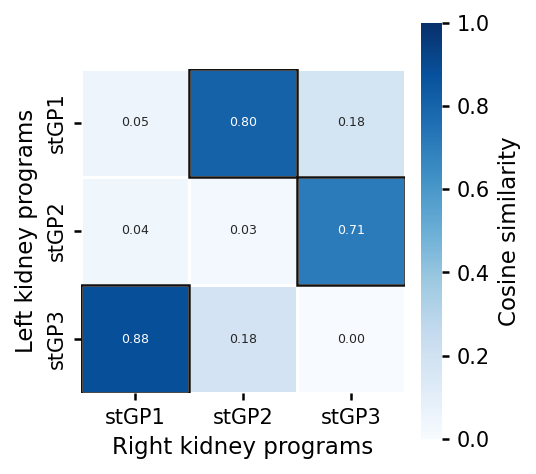

In [5]:
def program_pair_metrics(x: pd.Series, y: pd.Series) -> dict[str, float]:
    common = x.index.intersection(y.index)
    xv = x.loc[common].to_numpy(dtype=float)
    yv = y.loc[common].to_numpy(dtype=float)
    denom = max(np.linalg.norm(xv) * np.linalg.norm(yv), 1e-12)
    return {
        "cosine": float(np.dot(xv, yv) / denom),
        "pearson": float(pearsonr(xv, yv).statistic) if np.std(xv) > 0 and np.std(yv) > 0 else np.nan,
        "spearman": float(spearmanr(xv, yv).statistic) if np.std(xv) > 0 and np.std(yv) > 0 else np.nan,
    }


def build_baseline_aligned_lr_similarity() -> pd.DataFrame:
    align = base_sim.copy()
    align["baseline_program"] = align["program_a"]
    align["matched_program"] = align["program_b"]
    align = align.set_index(["setting_id", "side", "baseline_program"])

    rows = []
    manifest_cols = ["setting_id", "panel", "setting_label", "temporal_rho", "spatial_rho", "is_baseline"]
    for setting in manifest[manifest_cols].itertuples(index=False):
        w_l = load_w(setting.setting_id, "Immune_L")
        w_r = load_w(setting.setting_id, "Immune_R")
        for m in baseline_mapping.itertuples():
            left_prog = align.loc[(setting.setting_id, "Immune_L", m.program_a), "matched_program"]
            right_prog = align.loc[(setting.setting_id, "Immune_R", m.program_b), "matched_program"]
            row = {
                "setting_id": setting.setting_id,
                "panel": setting.panel,
                "setting_label": setting.setting_label,
                "temporal_rho": setting.temporal_rho,
                "spatial_rho": setting.spatial_rho,
                "is_baseline": setting.is_baseline,
                "baseline_left_program": m.program_a,
                "baseline_right_program": m.program_b,
                "left_program": left_prog,
                "right_program": right_prog,
                "match": f"{m.program_a} -> {m.program_b}",
                "current_match": f"{left_prog} -> {right_prog}",
            }
            row.update(program_pair_metrics(w_l.loc[left_prog], w_r.loc[right_prog]))
            rows.append(row)
    return pd.DataFrame(rows)


lr_plot = build_baseline_aligned_lr_similarity()
lr_plot["sweep_value"] = np.where(lr_plot["panel"].eq("temporal"), lr_plot["temporal_rho"], lr_plot["spatial_rho"])
lr_plot.to_csv(SOURCE / "fig2_left_right_similarity_source.csv", index=False)

LR_METRICS = {
    "cosine": "L/R W cosine",
    "pearson": "L/R W Pearson r",
    "spearman": "L/R W Spearman rho",
}
match_order = [f"{m.program_a} -> {m.program_b}" for m in baseline_mapping.itertuples()]
match_palette = sns.color_palette("colorblind", n_colors=len(match_order))
MATCH_COLORS = dict(zip(match_order, match_palette))
MATCH_LABELS = {
    f"{m.program_a} -> {m.program_b}": m.program_a
    for m in baseline_mapping.itertuples()
}


def plot_baseline_aligned_lr_sweep(panel: str, metric: str) -> plt.Figure:
    metric_label = LR_METRICS[metric]
    sub = lr_plot.loc[lr_plot["panel"].eq(panel)].copy()

    fig, ax = plt.subplots(figsize=(NM_W_HALF, 2.45), constrained_layout=False)
    fig.subplots_adjust(left=0.22, right=0.78, bottom=0.24, top=0.96)
    for match in match_order:
        df = sub.loc[sub["match"].eq(match)].sort_values("sweep_value")
        color = MATCH_COLORS[match]
        ax.plot(df["sweep_value"], df[metric], marker="o", ms=3.4, lw=1.2, color=color,
                markeredgecolor="white", markeredgewidth=0.35, label=MATCH_LABELS[match], zorder=3)

    y_min = 0 if metric == "cosine" else min(-0.10, float(sub[metric].min()) - 0.03)
    ax.set_ylim(y_min, 1.03)
    ax.margins(x=0.04)
    ax.set_xlabel("Temporal rho" if panel == "temporal" else "Spatial rho")
    ax.set_ylabel(metric_label)
    ax.legend(title="Left program", title_fontsize=6.2, fontsize=5.8, loc="center left",
              bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0, handlelength=1.8,
              frameon=False)
    return fig


w_l = load_w(baseline_id, "Immune_L")
w_r = load_w(baseline_id, "Immune_R")
cosmat = pd.DataFrame(cosine_similarity_matrix(w_l, w_r), index=w_l.index, columns=w_r.index)

fig, ax = plt.subplots(figsize=(NM_W_SINGLE, NM_W_SINGLE), constrained_layout=True)
sns.heatmap(cosmat, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True,
            cbar_kws={"label": "Cosine similarity", "shrink": 0.82},
            annot_kws={"fontsize": 6}, linewidths=0.5, linecolor="white", ax=ax)
for row in baseline_mapping.itertuples():
    i = list(cosmat.index).index(row.program_a)
    j = list(cosmat.columns).index(row.program_b)
    ax.add_patch(Rectangle((j, i), 1, 1, fill=False, ec="#111111", lw=1.2))
ax.set_xlabel("Right kidney programs")
ax.set_ylabel("Left kidney programs")
fig.savefig(SUMMARY / "fig2_left_right_baseline_matching.png", dpi=400, bbox_inches="tight")
plt.show()

## Figure 2. Left-anchored left/right reproducibility across kernels

For each Left baseline program, the matched Right program is fixed by the baseline similarity matrix and tracked across temporal and spatial kernel sweeps. Plot labels and legends use the Left cohort program definitions; the Right cohort programs have already been aligned to those Left programs. This avoids implying that same-numbered stGP labels are directly comparable across kidneys.

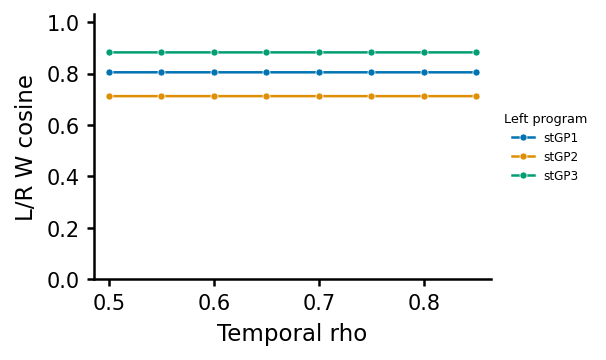

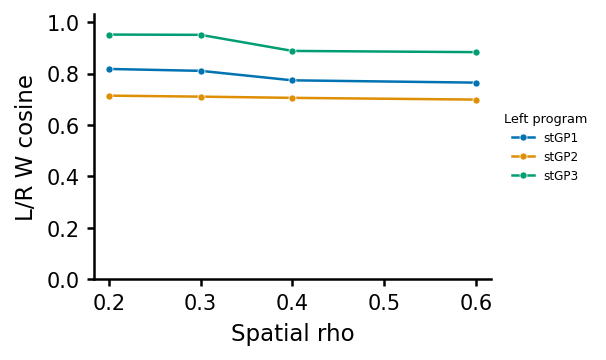

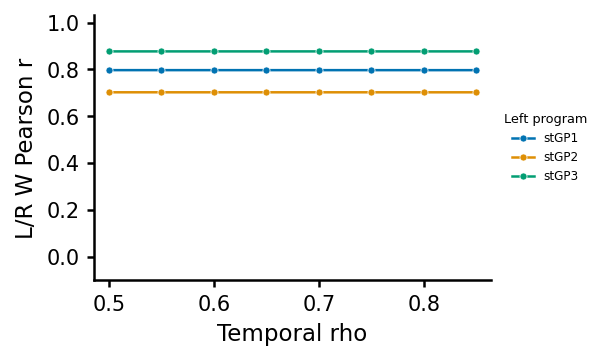

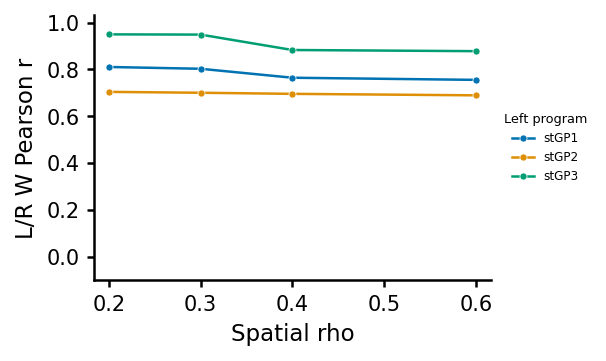

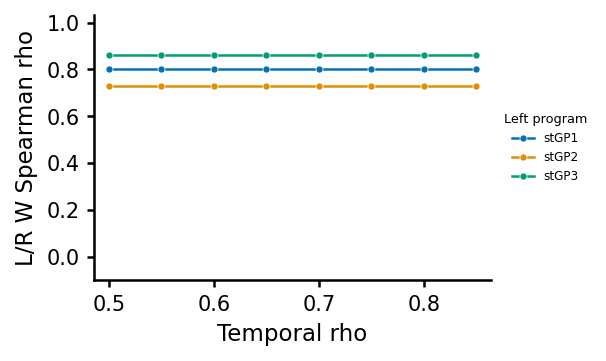

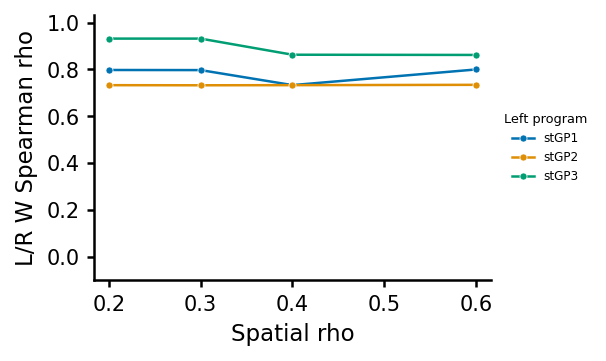

,min_cosine,median_cosine,min_pearson,median_pearson,min_spearman,median_spearman,n_matches
panel,,,,,,,
spatial,0.698715,0.792125,0.689003,0.783277,0.731933,0.797005,12
temporal,0.712141,0.804907,0.701926,0.796553,0.730532,0.800424,24


In [6]:
# Generate all left-anchored L/R reproducibility panels from one loop.
for metric in ["cosine", "pearson", "spearman"]:
    for panel in ["temporal", "spatial"]:
        fig = plot_baseline_aligned_lr_sweep(panel, metric)
        fig.savefig(SUMMARY / f"fig2_left_right_{panel}_{metric}.png", dpi=400, bbox_inches="tight")
        plt.show()

lr_plot.groupby("panel").agg(
    min_cosine=("cosine", "min"),
    median_cosine=("cosine", "median"),
    min_pearson=("pearson", "min"),
    median_pearson=("pearson", "median"),
    min_spearman=("spearman", "min"),
    median_spearman=("spearman", "median"),
    n_matches=("cosine", "size"),
)

## Figure 3. Kernel perturbations preserve the baseline programs

Each program from the baseline setting (`temporal rho=0.70`, `spatial rho=0.50`) is matched to the closest program from every robustness run within the same kidney. This separates numerical/kernel robustness from left/right biological replication.

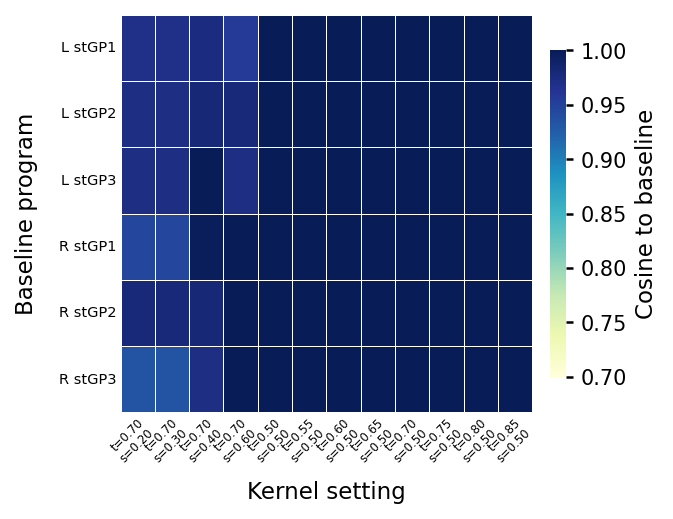

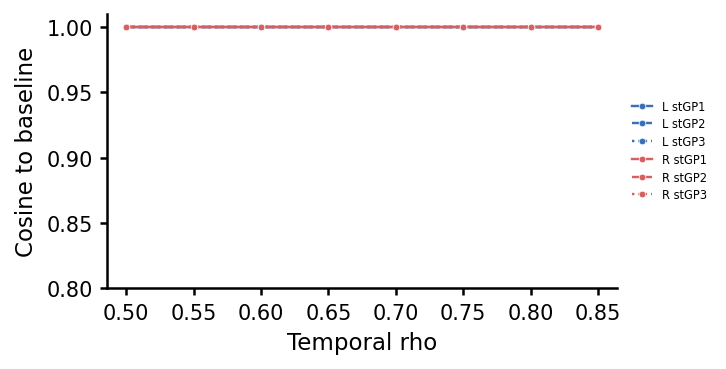

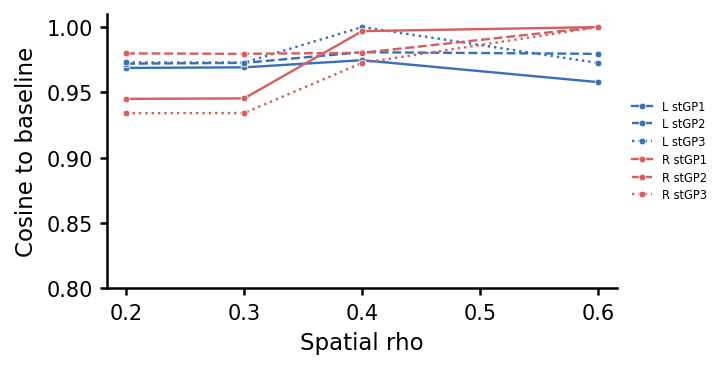

min_cosine  median_cosine   n
panel    side                                   
spatial  Immune_L    0.957800       0.972663  12
         Immune_R    0.933964       0.979653  12
temporal Immune_L    1.000000       1.000000  24
         Immune_R    1.000000       1.000000  24

In [7]:
robust_plot = base_sim.copy()
robust_plot["baseline_program"] = robust_plot["program_a"]
robust_plot["matched_program"] = robust_plot["program_b"]
robust_plot["sweep_value"] = np.where(robust_plot["panel"].eq("temporal"), robust_plot["temporal_rho"], robust_plot["spatial_rho"])
robust_plot["program_label"] = robust_plot["side"].str.replace("Immune_", "") + " " + robust_plot["baseline_program"]
robust_plot.to_csv(SOURCE / "fig3_baseline_similarity_source.csv", index=False)

heat = (robust_plot.groupby(["side", "baseline_program", "setting_id"], as_index=False)["cosine"].max()
        .merge(manifest[["setting_id", "setting_label", "panel", "temporal_rho", "spatial_rho"]], on="setting_id", how="left"))
heat["row"] = heat["side"].str.replace("Immune_", "") + " " + heat["baseline_program"]
setting_order = manifest.sort_values(["panel", "temporal_rho", "spatial_rho"])["setting_id"]
row_order = ["L stGP1", "L stGP2", "L stGP3", "R stGP1", "R stGP2", "R stGP3"]
piv = heat.pivot(index="row", columns="setting_id", values="cosine").reindex(index=row_order, columns=setting_order)

fig, ax = plt.subplots(figsize=(NM_W_FULL * 0.72, 3.9), constrained_layout=False)
fig.subplots_adjust(left=0.20, right=0.86, bottom=0.30, top=0.98)
sns.heatmap(piv, cmap="YlGnBu", vmin=0.70, vmax=1.0,
            cbar_kws={"label": "Cosine to baseline", "shrink": 0.82, "pad": 0.035},
            linewidths=0.35, linecolor="white", ax=ax)
setting_labels = manifest.set_index("setting_id").loc[setting_order, "setting_label"].str.replace(", ", "\n", regex=False)
ax.set_xticklabels(setting_labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=5.6)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
ax.set_xlabel("Kernel setting", labelpad=8)
ax.set_ylabel("Baseline program", labelpad=10)
ax.tick_params(axis="both", length=0, pad=2)
fig.savefig(SUMMARY / "fig3_program_identity_heatmap.png", dpi=400, bbox_inches="tight")
plt.show()


def plot_kernel_robustness_sweep(panel: str) -> plt.Figure:
    sub = robust_plot.loc[robust_plot["panel"].eq(panel)].copy()
    fig, ax = plt.subplots(figsize=(NM_W_HALF, 2.35), constrained_layout=True)
    for (side, prog), df in sub.groupby(["side", "baseline_program"]):
        df = df.sort_values("sweep_value")
        color = SIDE_COLORS[side]
        ls = {"stGP1": "-", "stGP2": "--", "stGP3": ":"}[prog]
        ax.plot(df["sweep_value"], df["cosine"], marker="o", ms=3.2, lw=1.15, ls=ls,
                color=color, markeredgecolor="white", markeredgewidth=0.35,
                label=f"{side.replace('Immune_', '')} {prog}")
    ax.set_ylim(0.8, 1.01)
    ax.margins(x=0.04)
    ax.set_xlabel("Temporal rho" if panel == "temporal" else "Spatial rho")
    ax.set_ylabel("Cosine to baseline")
    ax.legend(ncol=1, fontsize=5.5, loc="center left", bbox_to_anchor=(1.02, 0.5),
              borderaxespad=0.0, handlelength=1.8)
    return fig


for panel in ["temporal", "spatial"]:
    fig = plot_kernel_robustness_sweep(panel)
    fig.savefig(SUMMARY / f"fig3_{panel}_kernel_robustness.png", dpi=400, bbox_inches="tight")
    plt.show()

robust_plot.groupby(["panel", "side"]).agg(min_cosine=("cosine", "min"), median_cosine=("cosine", "median"), n=("cosine", "size"))

## Figure 4. Recurrent GO biology for the highlighted matched programs

GO terms are collected from the matched program in every kernel setting. The plot focuses on `L stGP3` and `R stGP1`, showing recurrent biological terms recovered at FDR < 0.05 across the robustness sweep.

In [8]:
go_terms_stgp_day2_immune = {
    "chemokine_leukocyte_recruitment": [
        "chemokine-mediated signaling pathway",
        "cellular response to chemokine",
        "response to chemokine",
        "chemokine production",
        "regulation of chemokine production",
        "positive regulation of chemokine production",
        "cytokine-mediated signaling pathway",
        "cellular response to cytokine stimulus",
        "response to cytokine",
        "leukocyte migration",
        "leukocyte chemotaxis",
        "leukocyte migration involved in inflammatory response",
        "regulation of leukocyte migration",
        "positive regulation of leukocyte migration",
        "regulation of leukocyte chemotaxis",
        "monocyte chemotaxis",
        "mononuclear cell migration",
        "macrophage migration",
        "macrophage chemotaxis",
        "myeloid leukocyte migration",
        "myeloid leukocyte chemotaxis",
        "neutrophil chemotaxis",
        "cell chemotaxis",
        "positive regulation of cell migration",
        "G protein-coupled receptor signaling pathway"
    ],

    "immune_inflammatory_activation": [
        "immune system process",
        "immune response",
        "regulation of immune response",
        "positive regulation of immune response",
        "defense response",
        "inflammatory response",
        "regulation of inflammatory response",
        "positive regulation of inflammatory response",
        "innate immune response",
        "leukocyte activation",
        "regulation of leukocyte activation",
        "positive regulation of leukocyte activation",
        "leukocyte mediated immunity",
        "myeloid leukocyte activation",
        "myeloid cell activation involved in immune response",
        "macrophage activation",
        "regulation of macrophage activation",
        "positive regulation of macrophage activation",
        "monocyte activation",
        "neutrophil activation",
        "neutrophil degranulation",
        "cytokine production",
        "regulation of cytokine production",
        "positive regulation of cytokine production",
        "response to interferon-gamma",
        "cellular response to interferon-gamma",
        "response to tumor necrosis factor",
        "cellular response to tumor necrosis factor",
        "response to lipopolysaccharide",
        "Toll-like receptor signaling pathway",
        "NF-kappaB signaling",
        "positive regulation of NF-kappaB transcription factor activity"
    ],

    "injury_repair_fibrotic_remodeling": [
        "response to wounding",
        "wound healing",
        "tissue remodeling",
        "regulation of tissue remodeling",
        "extracellular matrix organization",
        "regulation of extracellular matrix organization",
        "extracellular matrix disassembly",
        "collagen fibril organization",
        "collagen metabolic process",
        "collagen catabolic process",
        "collagen biosynthetic process",
        "regulation of collagen biosynthetic process",
        "cell adhesion",
        "regulation of cell adhesion",
        "positive regulation of cell adhesion",
        "cell-cell adhesion",
        "leukocyte cell-cell adhesion",
        "cell-substrate adhesion",
        "cell-matrix adhesion",
        "integrin-mediated signaling pathway",
        "fibroblast activation",
        "fibroblast proliferation",
        "regulation of fibroblast proliferation",
        "positive regulation of fibroblast proliferation",
        "transforming growth factor beta receptor signaling pathway",
        "response to transforming growth factor beta",
        "cellular response to transforming growth factor beta stimulus",
        "SMAD protein signal transduction",
        "regulation of SMAD protein signal transduction",
        "positive regulation of SMAD protein signal transduction",
        "regulation of epithelial to mesenchymal transition"
    ],

    "cell_cycle_cytokinesis": [
        "cell cycle",
        "mitotic cell cycle",
        "cell cycle process",
        "regulation of cell cycle",
        "cell division",
        "cytokinesis",
        "regulation of cytokinesis",
        "mitotic cytokinesis",
        "cell cycle G2 M phase transition",
        "G2/M transition of mitotic cell cycle",
        "mitotic cell cycle phase transition",
        "M phase of mitotic cell cycle",
        "nuclear division",
        "mitotic nuclear division",
        "chromosome segregation",
        "mitotic sister chromatid segregation",
        "DNA replication",
        "DNA replication initiation",
        "spindle organization",
        "mitotic spindle organization",
        "microtubule cytoskeleton organization involved in mitosis",
        "centrosome cycle",
        "contractile ring organization",
        "actomyosin structure organization"
    ],

    "autophagy_phagolysosome": [
        "autophagy",
        "macroautophagy",
        "regulation of autophagy",
        "positive regulation of autophagy",
        "selective autophagy",
        "autophagosome assembly",
        "autophagosome organization",
        "autophagosome maturation",
        "autophagosome membrane docking",
        "autophagosome-lysosome fusion",
        "lysosome organization",
        "lysosomal transport",
        "vacuolar transport",
        "endocytosis",
        "receptor-mediated endocytosis",
        "phagocytosis",
        "phagocytosis, engulfment",
        "phagosome maturation",
        "phagosome acidification",
        "apoptotic cell clearance",
        "antigen processing and presentation",
        "antigen processing and presentation of exogenous peptide antigen via MHC class II"
    ],

    "mitochondrial_er_stress_quality_control": [
        "mitochondrion organization",
        "mitochondrial transport",
        "mitochondrial transmembrane transport",
        "mitochondrial protein import",
        "protein targeting to mitochondrion",
        "protein localization to mitochondrion",
        "establishment of protein localization to mitochondrion",
        "protein localization to mitochondrial membrane",
        "establishment of protein localization to mitochondrial membrane",
        "mitochondrion-endoplasmic reticulum membrane tethering",
        "mitochondrial fission",
        "mitochondrial fusion",
        "mitophagy",
        "regulation of mitophagy",
        "regulation of mitochondrial membrane potential",
        "response to oxidative stress",
        "reactive oxygen species metabolic process",
        "cellular response to reactive oxygen species",
        "response to decreased oxygen levels",
        "cellular response to hypoxia",
        "regulation of apoptotic process",
        "intrinsic apoptotic signaling pathway in response to oxidative stress"
    ],

    "calcium_transporter_amine_optional": [
        "calcium ion transport",
        "calcium ion transmembrane transport",
        "regulation of calcium ion transport",
        "regulation of calcium ion transmembrane transport",
        "negative regulation of calcium ion transmembrane transporter activity",
        "transmembrane transport",
        "regulation of transmembrane transport",
        "negative regulation of transporter activity",
        "regulation of ion transmembrane transport",
        "response to amine",
        "cellular response to amine stimulus",
        "response to catecholamine",
        "response to dopamine"
    ],

    "molecular_function_terms": [
        "chemokine activity",
        "chemokine receptor binding",
        "CCR chemokine receptor binding",
        "cytokine activity",
        "cytokine receptor binding",
        "growth factor activity",
        "transforming growth factor beta receptor binding",
        "signaling receptor activator activity",
        "receptor ligand activity",
        "G protein-coupled receptor binding",
        "integrin binding",
        "collagen binding",
        "extracellular matrix binding",
        "extracellular matrix structural constituent",
        "heparin binding",
        "transporter inhibitor activity",
        "ion channel inhibitor activity"
    ],

    "cellular_component_terms": [
        "extracellular region",
        "extracellular space",
        "secretory granule lumen",
        "cell surface",
        "external side of plasma membrane",
        "plasma membrane",
        "lysosome",
        "lytic vacuole",
        "phagocytic vesicle",
        "phagosome",
        "autophagosome",
        "autolysosome",
        "mitochondrion",
        "mitochondrial membrane",
        "mitochondrial outer membrane",
        "endoplasmic reticulum",
        "endoplasmic reticulum membrane",
        "mitochondria-associated endoplasmic reticulum membrane",
        "collagen-containing extracellular matrix",
        "focal adhesion",
        "cell-substrate junction"
    ]
}

## Fig6 robustness publication panels

The following cell displays the Fig6 robustness panels generated from this summary notebook's source-data exports.

In [ ]:
from IPython.display import Image, display

fig6_panels = [
    SUMMARY / "fig2_left_right_baseline_matching.png",
    SUMMARY / "fig5_baseline_gene_signatures.png",
    SUMMARY / "fig4_go_recurrence.png",
]
for path in fig6_panels:
    if path.exists():
        print(path)
        display(Image(filename=str(path)))
    else:
        print(f"Missing Fig6 robustness panel: {path}")

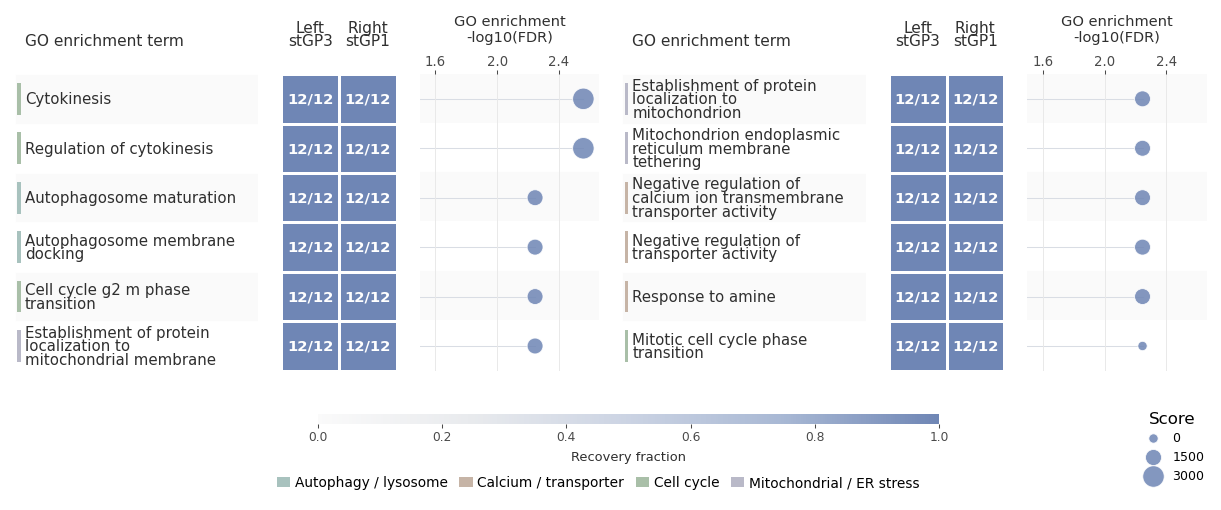

In [31]:
def build_matched_go_table(fdr_cutoff: float = 0.10) -> pd.DataFrame:
    go_rows = []
    # Map each setting-side-baseline program to the matched program in that setting.
    match = robust_plot[["side", "setting_id", "baseline_program", "matched_program", "cosine"]].copy()
    for (setting_id, side_label), mdf in match.groupby(["setting_id", "side"]):
        go = load_go(setting_id, side_label)
        for row in mdf.itertuples():
            sub = go.loc[go["program"].eq(row.matched_program)].copy()
            if sub.empty:
                continue
            sub["baseline_program"] = row.baseline_program
            sub["matched_program"] = row.matched_program
            sub["match_cosine"] = row.cosine
            sub["side_label"] = side_label
            sub["setting_id"] = setting_id
            go_rows.append(sub)
    out = pd.concat(go_rows, ignore_index=True)
    out["Term_clean"] = out["Term"].map(lambda term: clean_term(term, max_len=160))
    out["is_recovered"] = pd.to_numeric(out["Adjusted P-value"], errors="coerce") < fdr_cutoff
    return out


def normalize_go_label(term: str) -> str:
    s = str(term)
    s = re.sub(r"^(GOBP|GOCC|GOMF|HALLMARK|REACTOME|KEGG|WP)_", "", s)
    s = s.replace("_", " ").lower()
    s = re.sub(r"[^a-z0-9]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()


theme_label_map = {
    "chemokine_leukocyte_recruitment": "Chemokine / recruitment",
    "immune_inflammatory_activation": "Immune activation",
    "injury_repair_fibrotic_remodeling": "Repair / remodeling",
    "cell_cycle_cytokinesis": "Cell cycle",
    "autophagy_phagolysosome": "Autophagy / lysosome",
    "mitochondrial_er_stress_quality_control": "Mitochondrial / ER stress",
    "calcium_transporter_amine_optional": "Calcium / transporter",
    "molecular_function_terms": "Molecular function",
    "cellular_component_terms": "Cellular component",
}

candidate_term_to_theme = {}
for theme, terms in go_terms_stgp_day2_immune.items():
    for term in terms:
        candidate_term_to_theme.setdefault(normalize_go_label(term), theme)

go_matched = build_matched_go_table(fdr_cutoff=0.05)
go_matched = go_matched.merge(manifest[["setting_id", "panel", "temporal_rho", "spatial_rho"]], on="setting_id", how="left")
go_matched = go_matched[go_matched["gene_set"].eq("GO Biological Process")].copy()
go_matched["Adjusted P-value"] = pd.to_numeric(go_matched["Adjusted P-value"], errors="coerce")
go_matched["Combined Score"] = pd.to_numeric(go_matched["Combined Score"], errors="coerce")
go_matched["candidate_theme"] = go_matched["Term_clean"].map(lambda term: candidate_term_to_theme.get(normalize_go_label(term)))
go_matched["candidate_theme_label"] = go_matched["candidate_theme"].map(theme_label_map)
go_matched["is_candidate_term"] = go_matched["candidate_theme"].notna()

go_recovered = go_matched.loc[go_matched["is_recovered"]].copy()
go_recovered.to_csv(SOURCE / "fig4_matched_go_terms_source.csv", index=False)

go_candidate_recovered = go_recovered.loc[go_recovered["is_candidate_term"]].copy()
go_candidate_recovered.to_csv(SOURCE / "fig4_candidate_matched_go_terms_source.csv", index=False)
if go_candidate_recovered.empty:
    raise ValueError("No recovered GO Biological Process terms matched go_terms_stgp_day2_immune.")

# Recovery fraction uses all kernel settings as the denominator; enrichment strength uses
# the strongest recovered signal, i.e. max -log10(FDR), equivalent to the minimum adjusted p-value.
setting_counts = (robust_plot.groupby(["side", "baseline_program"], as_index=False)["setting_id"]
                  .nunique()
                  .rename(columns={"side": "side_label", "setting_id": "n_settings"}))
rec = (go_candidate_recovered.groupby(["side_label", "baseline_program", "gene_set", "Term_clean", "candidate_theme", "candidate_theme_label"], as_index=False)
       .agg(n_recovered=("setting_id", "nunique"),
            best_padj=("Adjusted P-value", "min"),
            median_score=("Combined Score", "median")))
rec = rec.merge(setting_counts, on=["side_label", "baseline_program"], how="left")
rec["recurrence"] = rec["n_recovered"] / rec["n_settings"].replace(0, np.nan)
rec["max_neglog_fdr"] = -np.log10(rec["best_padj"].clip(lower=1e-300))
rec["program_side"] = rec["side_label"].str.replace("Immune_", "") + " " + rec["baseline_program"]

target_programs = [
    ("Immune_L", "stGP3"),
    ("Immune_R", "stGP1"),
]
target_labels = ["L stGP3", "R stGP1"]

top_n_per_program = 10
selected_terms = []
for side, prog in target_programs:
    df = rec.loc[rec["side_label"].eq(side) & rec["baseline_program"].eq(prog)].copy()
    top_terms = df.sort_values(["recurrence", "median_score", "max_neglog_fdr"], ascending=False).head(top_n_per_program)
    selected_terms.extend(top_terms["Term_clean"])

exclude_terms = {
    "Bone trabecula formation",
    "Bone trabecula morphogenesis",
    "Direct ossification",
    "Trabecula formation",
    "Cellular response to estradiol stimulus",
    "Modified amino acid binding",
    "Intramolecular oxidoreductase activity transposing c c bonds",
    "Disruption of anatomical structure in another organism",
}
selected_terms = list(dict.fromkeys(term for term in selected_terms if term not in exclude_terms))

plot_rec = rec.loc[rec["Term_clean"].isin(selected_terms) & rec["program_side"].isin(target_labels)].copy()
if plot_rec.empty:
    raise ValueError("No selected candidate GO terms remained for plotting.")
term_rank = (plot_rec.groupby("Term_clean", as_index=False)
             .agg(recurrence=("recurrence", "max"),
                  n_recovered=("n_recovered", "max"),
                  n_settings=("n_settings", "max"),
                  best_padj=("best_padj", "min"),
                  median_score=("median_score", "max"),
                  max_neglog_fdr=("max_neglog_fdr", "max"),
                  candidate_theme=("candidate_theme", "first"),
                  candidate_theme_label=("candidate_theme_label", "first")))
term_order = term_rank.sort_values(["recurrence", "median_score", "max_neglog_fdr"], ascending=False)["Term_clean"].tolist()
piv = (plot_rec.pivot_table(index="Term_clean", columns="program_side", values="recurrence", aggfunc="max")
       .reindex(index=term_order, columns=target_labels).fillna(0))
enrich_summary = term_rank.set_index("Term_clean").reindex(term_order).reset_index()
enrich_summary.to_csv(SOURCE / "fig4_go_enrichment_summary.csv", index=False)

import math
import textwrap
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import MaxNLocator

plot_matrix = piv.reindex(index=term_order, columns=target_labels).fillna(0)
count_matrix = (plot_rec.pivot_table(index="Term_clean", columns="program_side", values="n_recovered", aggfunc="max")
                .reindex(index=term_order, columns=target_labels).fillna(0).astype(int))
summary_by_term = enrich_summary.set_index("Term_clean")
target_denoms = {
    label: int(setting_counts.loc[
        setting_counts["side_label"].eq(side) & setting_counts["baseline_program"].eq(prog),
        "n_settings",
    ].iloc[0])
    for (side, prog), label in zip(target_programs, target_labels)
}
ratio_labels = count_matrix.copy().astype(str)
for label in target_labels:
    ratio_labels[label] = count_matrix[label].map(lambda n: f"{int(n)}/{target_denoms[label]}")

cmap = LinearSegmentedColormap.from_list("muted_recovery_blue", ["#FAFAFA", "#E8EAED", "#CBD3E3", "#A8B8D4", "#6F86B5"])
theme_palette = {
    "chemokine_leukocyte_recruitment": "#9FB8CF",
    "immune_inflammatory_activation": "#B8A7C9",
    "injury_repair_fibrotic_remodeling": "#C9B49B",
    "cell_cycle_cytokinesis": "#A9BFA8",
    "autophagy_phagolysosome": "#A8C2BE",
    "mitochondrial_er_stress_quality_control": "#B9B9C8",
    "calcium_transporter_amine_optional": "#C6B4A6",
    "molecular_function_terms": "#BFC1A6",
    "cellular_component_terms": "#B8B8B8",
}

n_terms = len(term_order)
split_at = math.ceil(n_terms / 2)
term_chunks = [term_order[:split_at], term_order[split_at:]]
fig_w = NM_W_FULL * 1.18
fig_h = fig_w / 1.95
fig = plt.figure(figsize=(fig_w, fig_h), constrained_layout=False)
gs = fig.add_gridspec(2, 6, width_ratios=[1.52, 0.72, 1.12, 1.52, 0.72, 1.12],
                      height_ratios=[1, 0.065], wspace=0.13, hspace=0.24)
fig.subplots_adjust(left=0.035, right=0.985, bottom=0.215, top=0.765)
cax = fig.add_subplot(gs[1, 1:5])

score = enrich_summary["median_score"].fillna(0).to_numpy(float)
score_min = float(np.nanmin(score)) if len(score) else 0.0
score_max = float(np.nanmax(score)) if len(score) else 1.0
score_span = score_max - score_min
score_to_size = lambda s: 42.0 if score_span <= 0 else 20 + 86 * (float(s) - score_min) / score_span
xmin = 1.5
xmax = max(xmin + 0.35, float(enrich_summary["max_neglog_fdr"].max()) * 1.04)
fs = {"term": 7.2 if split_at <= 10 else 6.8, "ratio": 7.1, "header": 7.4, "axis": 7.0, "tick": 6.4}
header_labels = [f"{'Left' if side.endswith('_L') else 'Right'}\n{prog}" for side, prog in target_programs]


def draw_go_block(terms, block_idx: int, show_cbar: bool):
    col0 = block_idx * 3
    term_ax, heat_ax, enrich_ax = [fig.add_subplot(gs[0, col0 + i]) for i in range(3)]
    block_matrix = plot_matrix.reindex(index=terms)
    block_summary = summary_by_term.reindex(terms).reset_index()
    n_block = len(terms)

    sns.heatmap(
        block_matrix, cmap=cmap, vmin=0, vmax=1,
        annot=ratio_labels.reindex(index=terms), fmt="",
        annot_kws={"fontsize": fs["ratio"], "fontweight": "bold"},
        linewidths=0.62, linecolor="white", xticklabels=False, yticklabels=False,
        cbar=show_cbar, cbar_ax=cax if show_cbar else None,
        cbar_kws={"orientation": "horizontal", "label": "Recovery fraction"} if show_cbar else None,
        ax=heat_ax,
    )
    for text, value in zip(heat_ax.texts, block_matrix.to_numpy().ravel()):
        text.set(color="white" if value >= 0.70 else "#2F2F2F", fontsize=fs["ratio"], fontweight="bold")
    for x, label in enumerate(header_labels):
        heat_ax.text(x + 0.5, -0.52, label, ha="center", va="bottom", fontsize=fs["header"],
                     color="#2F2F2F", linespacing=0.85, clip_on=False)
    heat_ax.tick_params(axis="both", length=0, pad=0, labeltop=False, labelbottom=False)
    heat_ax.set(xlabel="", ylabel="")

    term_ax.set(xlim=(0, 1), ylim=(n_block, 0))
    term_ax.axis("off")
    for y, row in block_summary.iterrows():
        bg = "#FAFAFA" if y % 2 == 0 else "#FFFFFF"
        theme_color = theme_palette.get(row.candidate_theme, "#B8B8B8")
        term_ax.add_patch(Rectangle((0, y), 1, 1, facecolor=bg, edgecolor="white", linewidth=0.40))
        term_ax.add_patch(Rectangle((0.010, y + 0.18), 0.014, 0.64, facecolor=theme_color, edgecolor="none"))
        enrich_ax.axhspan(y, y + 1, color=bg, zorder=0)
        term_ax.text(0.040, y + 0.5, textwrap.fill(row.Term_clean, width=27), ha="left", va="center",
                     fontsize=fs["term"], color="#2F2F2F", linespacing=0.88)
    term_ax.text(0.040, -0.52, "GO enrichment term", ha="left", va="bottom", fontsize=fs["header"], color="#2F2F2F")

    y_pos = np.arange(n_block) + 0.5
    x_vals = block_summary["max_neglog_fdr"].to_numpy(float)
    sizes = [score_to_size(s) for s in block_summary["median_score"].fillna(0)]
    for y, x in zip(y_pos, x_vals):
        enrich_ax.plot([xmin, max(xmin, x)], [y, y], color="#D9DDE4", lw=0.50, zorder=1)
    enrich_ax.scatter(x_vals, y_pos, s=sizes, color="#6F86B5", alpha=0.86,
                      edgecolor="white", linewidth=0.42, zorder=3)
    enrich_ax.set(xlim=(xmin, xmax), ylim=(n_block, 0), yticks=[])
    enrich_ax.xaxis.tick_top()
    enrich_ax.xaxis.set_label_position("top")
    enrich_ax.set_xlabel("GO enrichment\n-log10(FDR)", fontsize=fs["axis"], labelpad=6, color="#2F2F2F")
    enrich_ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
    enrich_ax.tick_params(axis="x", labelsize=fs["tick"], width=0.50, length=2, pad=1, colors="#4A4A4A")
    enrich_ax.grid(axis="x", color="#E8E8E8", lw=0.45)
    for spine in ["left", "right", "bottom"]:
        enrich_ax.spines[spine].set_visible(False)
    enrich_ax.spines["top"].set(linewidth=0.50, color="#777777")
    return enrich_ax

score_ax = None
for block_idx, terms in enumerate(term_chunks):
    if terms:
        score_ax = draw_go_block(terms, block_idx, show_cbar=(block_idx == 0))

if score_span > 0 and score_ax is not None:
    legend_scores = np.unique(np.array([
        np.floor(score_min / 500) * 500,
        np.round(np.nanmedian(score) / 500) * 500,
        np.ceil(score_max / 500) * 500,
    ]).astype(int))
    score_handles = [score_ax.scatter([], [], s=score_to_size(np.clip(s, score_min, score_max)), color="#6F86B5",
                                      alpha=0.86, edgecolor="white", linewidth=0.42, label=f"{s:.0f}")
                     for s in legend_scores]
    score_ax.legend(handles=score_handles, title="Score", loc="lower right", bbox_to_anchor=(1.03, -0.4),
                    fontsize=6, title_fontsize=8, frameon=False, borderpad=0.1,
                    handletextpad=0.55, labelspacing=0.45)

used_themes = (enrich_summary[["candidate_theme", "candidate_theme_label"]]
               .dropna().drop_duplicates().sort_values("candidate_theme_label"))
if not used_themes.empty:
    theme_handles = [Patch(facecolor=theme_palette.get(row.candidate_theme, "#B8B8B8"), edgecolor="none",
                           label=row.candidate_theme_label)
                     for row in used_themes.itertuples(index=False)]
    fig.legend(handles=theme_handles, loc="lower center", bbox_to_anchor=(0.50, 0.1),
               ncol=min(4, len(theme_handles)), fontsize=6.6, title_fontsize=5.7, frameon=False,
               handlelength=0.95, handletextpad=0.35, columnspacing=0.85)

cax.tick_params(labelsize=5.9, width=0.50, length=2, pad=1, colors="#4A4A4A")
cax.xaxis.label.set_size(6.25)
cax.xaxis.label.set_color("#2F2F2F")
cax_pos = cax.get_position()
cax.set_position([cax_pos.x0 + cax_pos.width * 0.05, cax_pos.y0 + cax_pos.height * 0.18,
                  cax_pos.width * 0.86, cax_pos.height * 0.54])
fig.savefig(SUMMARY / "fig4_go_recurrence.png", dpi=400, bbox_inches="tight", pad_inches=0.06)
piv.to_csv(SOURCE / "fig4_go_recurrence_matrix.csv")
count_matrix.to_csv(SOURCE / "fig4_go_recurrence_counts.csv")
plt.show()

## Figure 5. Baseline program signatures across biological replicates

This figure displays the union of top W genes from the baseline left/right matched programs. It is intended as a compact biological summary panel to pair with the quantitative robustness panels above.

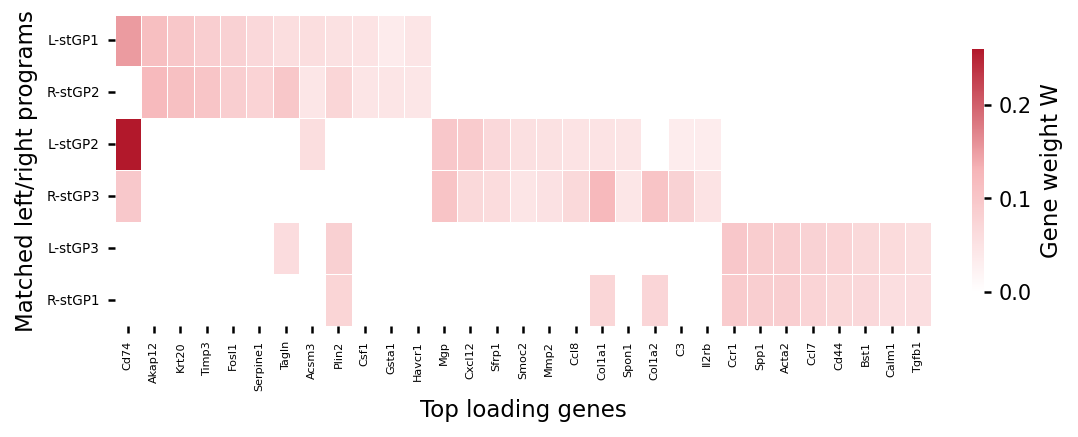

In [10]:
w_l = load_w(baseline_id, "Immune_L")
w_r = load_w(baseline_id, "Immune_R")
w_row_sums = pd.concat(
    [w_l.sum(axis=1).rename("row_sum").to_frame().assign(side="Immune_L"),
     w_r.sum(axis=1).rename("row_sum").to_frame().assign(side="Immune_R")]
).rename_axis("program").reset_index()
w_row_sums.to_csv(SOURCE / "fig5_baseline_w_row_sums.csv", index=False)
if not np.allclose(w_row_sums["row_sum"], 1.0, atol=1e-6):
    raise ValueError("Expected each W row to sum to 1 before plotting raw loadings.")

rows = []
genes = []
for m in baseline_mapping.itertuples():
    for side_label, prog, w in [("Immune_L", m.program_a, w_l), ("Immune_R", m.program_b, w_r)]:
        label = side_program_display_name(side_label, prog)
        rows.append(label)
        top = w.loc[prog][w.loc[prog] > 0].sort_values(ascending=False).head(10).index.tolist()
        genes.extend(top)
genes = list(dict.fromkeys(genes))

sig = pd.DataFrame(index=rows, columns=genes, dtype=float)
for m in baseline_mapping.itertuples():
    for side_label, prog, w in [("Immune_L", m.program_a, w_l), ("Immune_R", m.program_b, w_r)]:
        label = side_program_display_name(side_label, prog)
        sig.loc[label] = w.loc[prog, genes].astype(float)
sig = sig.fillna(0)
sig.to_csv(SOURCE / "fig5_baseline_signature_matrix.csv")

fig, ax = plt.subplots(figsize=(NM_W_FULL, 2.8), constrained_layout=True)
cmap = LinearSegmentedColormap.from_list("wload", ["#FFFFFF", "#F6B5B8", "#B2182B"])
sns.heatmap(
    sig,
    cmap=cmap,
    vmin=0,
    vmax=float(sig.to_numpy().max()),
    xticklabels=1,
    cbar_kws={"label": "Gene weight W", "shrink": 0.78},
    linewidths=0.25,
    linecolor="white",
    ax=ax,
)
ax.set_xlabel("Top loading genes")
ax.set_ylabel("Matched left/right programs")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=5.4)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6.5)
fig.savefig(SUMMARY / "fig5_baseline_gene_signatures.png", dpi=400, bbox_inches="tight")
plt.show()